# Análisis de datos - TP Final

## Integrantes
- Jonatan Mild
- Valentin Torres
- Alan Cornejo

## Dataset seleccionado
[Full TMDB Movies Dataset 2024](https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies)

## Exploración y comprensión de los datos

#### Cargar el dataset proporcionado y realizar un análisis exploratorio de los datos.


##### Imports y config

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import kagglehub
from scipy import stats as st
from scipy.stats import describe

pd.options.display.float_format = '{:,.4f}'.format
pd.set_option("display.max_columns", None)

##### Carga del dataset y estructura

In [34]:
# Download latest version
path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

print("Path to dataset files:", path)

df = pd.read_csv(path + "/TMDB_movie_dataset_v11.csv", na_values='sin especificar', encoding='ISO-8859-1')
df.head()

Path to dataset files: /home/jbmild/.cache/kagglehub/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/versions/913


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.3640,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,160000000,https://www.warnerbros.com/movies/inception,tt1375666,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.9520,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.4170,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,165000000,http://www.interstellarmovie.net/,tt0816692,en,Interstellar,The adventures of a group of explorers who mak...,140.2410,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.5120,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,185000000,https://www.warnerbros.com/movies/dark-knight/,tt0468569,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.6430,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.5730,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,https://www.avatar.com/movies/avatar,tt0499549,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.9320,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.7100,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,220000000,https://www.marvel.com/movies/the-avengers,tt0848228,en,The Avengers,When an unexpected enemy emerges and threatens...,98.0820,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [35]:
df.tail()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
1409150,898253,No se puede ver el sol o morir por mucho tiempo,0.0000,0,Released,2021-11-20,0,4,False,NaN,0,NaN,NaN,en,No se puede ver el sol o morir por mucho tiempo,NaN,0.6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1409151,253236,I Carry the Gift,0.0000,0,Released,2014-02-22,0,120,False,NaN,0,http://pretzyls.wix.com/icarrythegift,tt3341096,en,I Carry the Gift,Adam Cullin is a well-intended family man whos...,0.6380,NaN,"I hear"" Voices"" in my head!",Drama,NaN,United States of America,English,NaN
1409152,898256,Ramal Infinito,0.0000,0,Released,2021-11-20,0,3,False,NaN,0,NaN,NaN,en,Ramal Infinito,NaN,0.6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1409153,898257,Solo el viento,0.0000,0,Released,2021-11-20,0,4,False,NaN,0,NaN,NaN,en,Solo el viento,NaN,0.6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1409154,1677624,You Say We Aren't Objects...,0.0000,0,Released,2026-04-20,0,12,False,NaN,0,NaN,NaN,en,You Say We Aren't Objects...,A collection of anonymously shared stories det...,0.0143,/u45UXNRn0bViLiHOvocspHtacw5.jpg,NaN,"Documentary, Drama",NaN,NaN,NaN,NaN


#### Describir las características principales del dataset, incluyendo el número de observaciones, número de variables y tipos de datos.

In [36]:
df.shape

(1409155, 24)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409155 entries, 0 to 1409154
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1409155 non-null  int64  
 1   title                 1409137 non-null  object 
 2   vote_average          1409155 non-null  float64
 3   vote_count            1409155 non-null  int64  
 4   status                1409155 non-null  object 
 5   release_date          1098557 non-null  object 
 6   revenue               1409155 non-null  int64  
 7   runtime               1409155 non-null  int64  
 8   adult                 1409155 non-null  bool   
 9   backdrop_path         350819 non-null   object 
 10  budget                1409155 non-null  int64  
 11  homepage              145078 non-null   object 
 12  imdb_id               666022 non-null   object 
 13  original_language     1409155 non-null  object 
 14  original_title        1409137 non-

### Descripción de las características principales

A partir de la exploración inicial, observamos que el dataset cuenta con **1.407.834 observaciones** (películas) y **24 variables**. Estas variables se clasifican en los siguientes tipos:

* **Variables Numéricas (7):** `id`, `vote_count`, `revenue`, `runtime`, `budget` (discretas tipo int64); y `vote_average`, `popularity` (continuas tipo float64).
* **Variables Categóricas / Texto (16):** `title`, `status`, `release_date`, `original_language`, `genres`, `production_companies`, `production_countries`, entre otras (tipo object).
* **Variables Booleanas (1):** `adult` (tipo bool).

**Observaciones de Calidad de Datos (Data Cleaning):**
A simple vista detectamos que la variable `release_date` figura como tipo texto (`object`) y deberá ser convertida a formato fecha (`datetime`). Además, el análisis de completitud (`Non-Null Count`) revela que columnas como `homepage`, `tagline` y `backdrop_path` tienen una proporción masiva de datos faltantes, los cuales requerirán un análisis profundo para determinar su tipo (MCAR, MAR, MNAR) y su posterior tratamiento.

##### Numericas

###### id, vote_average, vote_count, revenue, runtime, budget, popularity

##### Categorias

###### title, status, release_date, backdrop_path, homepage, imdb_id, original_title, overview, poster_path, tagline, genres, production_companies, production_countries, spoken_languages, keywords

##### Booleanas

###### adult

#### Identificar patrones generales y distribuciones.


In [38]:
# Función para calcular la entropía de Shannon vista en clase
def shannon_entropy(y):
    probs = y.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs))

##### Numericas

In [39]:
# Análisis descriptivo de las variables numéricas
columnas_numericas = ['vote_average', 'vote_count', 'revenue', 'runtime', 'budget', 'popularity']

# Utilizamos describe() y formateamos la salida para evitar notación científica y facilitar la lectura
df_num_stats = df[columnas_numericas].describe().apply(lambda s: s.apply('{0:,.2f}'.format))
display(df_num_stats)

,vote_average,vote_count,revenue,runtime,budget,popularity
count,"1,409,155.00","1,409,155.00","1,409,155.00","1,409,155.00","1,409,155.00","1,409,155.00"
mean,1.56,15.23,"621,166.50",44.09,"236,767.57",1.02
std,2.86,286.16,"19,306,871.48",60.68,"5,089,088.47",6.83
min,0.00,0.00,-12.00,-28.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.05
50%,0.00,0.00,0.00,16.00,0.00,0.60
75%,1.00,1.00,0.00,85.00,0.00,0.71
max,10.00,"34,495.00","4,999,999,999.00","14,400.00","999,999,999.00","2,994.36"


Analizando la estadística descriptiva de las variables numéricas, identificamos los siguientes patrones y anomalías:

1. **Asimetría (Skewness) y dispersión:** Variables económicas como `revenue` (recaudación) y `budget` (presupuesto), así como `popularity` y `vote_count`, presentan valores máximos extremadamente alejados de su media y del percentil 75%. Esto nos indica que sus distribuciones están fuertemente sesgadas hacia la derecha (asimetría positiva), lo cual es lógico en la industria del cine, donde unas pocas superproducciones acaparan la mayor recaudación y popularidad, mientras que la inmensa mayoría de las películas son de bajo presupuesto.
2. **Datos faltantes encubiertos (Anomalías):** Observando el valor mínimo (`min`) de columnas como `runtime`, `budget` y `revenue`, notamos que es `0.00`. Una película estrenada no puede tener una duración o un presupuesto de cero. Esto indica que existen datos faltantes que fueron registrados como ceros por error en la base de datos original. Durante la etapa de limpieza de datos (Data Cleaning), estos ceros deberán ser tratados como nulos.


##### Categoricas

In [40]:
cat_vars = ['status', 'adult', 'original_language', 'genres', 'production_countries', 'production_companies', 'spoken_languages']
resultados_cat = []

for col in cat_vars:
    # Ignoramos los nulos temporariamente para el cálculo
    serie_valida = df[col].dropna()
    
    # Cálculos
    cardinalidad = serie_valida.nunique()
    moda = serie_valida.mode()
    prop_moda = serie_valida.value_counts(normalize=True).iloc[0] * 100
    entropia = shannon_entropy(serie_valida)
    
    resultados_cat.append({
        'Variable': col,
        'Cardinalidad (Valores Únicos)': cardinalidad,
        'Moda': moda,
        '% de Concentración de la Moda': round(prop_moda, 2),
        'Entropía de Shannon': round(entropia, 2)
    })

# Convertimos a DataFrame para visualizarlo como una tabla bonita
df_stats_categoricas = pd.DataFrame(resultados_cat)
print("--- Estadísticas Descriptivas de Variables Categóricas ---")
display(df_stats_categoricas)

--- Estadísticas Descriptivas de Variables Categóricas ---


,Variable,Cardinalidad (Valores Únicos),Moda,% de Concentración de la Moda,Entropía de Shannon
0,status,6,"0 Released Name: status, dtype: object",96.4700,0.2800
1,adult,2,"0 False Name: adult, dtype: bool",90.0500,0.4700
2,original_language,177,"0 en Name: original_language, dtype: object",54.6900,3.1000
3,genres,15010,"0 Documentary Name: genres, dtype: object",20.4000,6.1400
4,production_countries,11050,0 United States of America Name: production...,27.3700,5.3700
5,production_companies,235350,"0 Evil Angel Name: production_companies, dt...",0.5200,15.5200
6,spoken_languages,7528,"0 English Name: spoken_languages, dtype: ob...",35.3400,4.7300


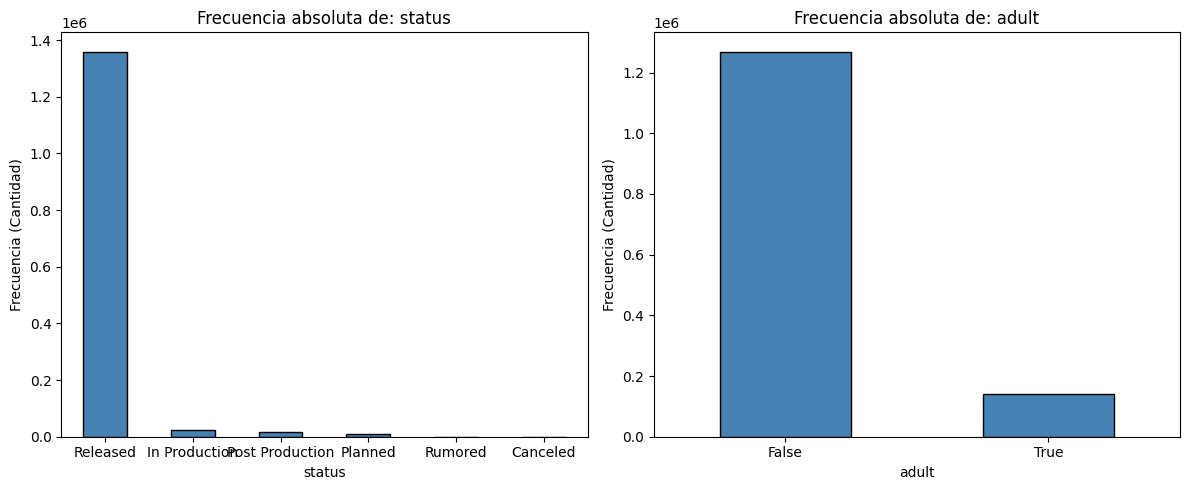

In [41]:
baja_card_vars = ['status', 'adult']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes.ravel(), baja_card_vars):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Frecuencia absoluta de: {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia (Cantidad)')
    ax.tick_params(axis='x', rotation=0) # Mantiene las etiquetas horizontales

plt.tight_layout()
plt.show()

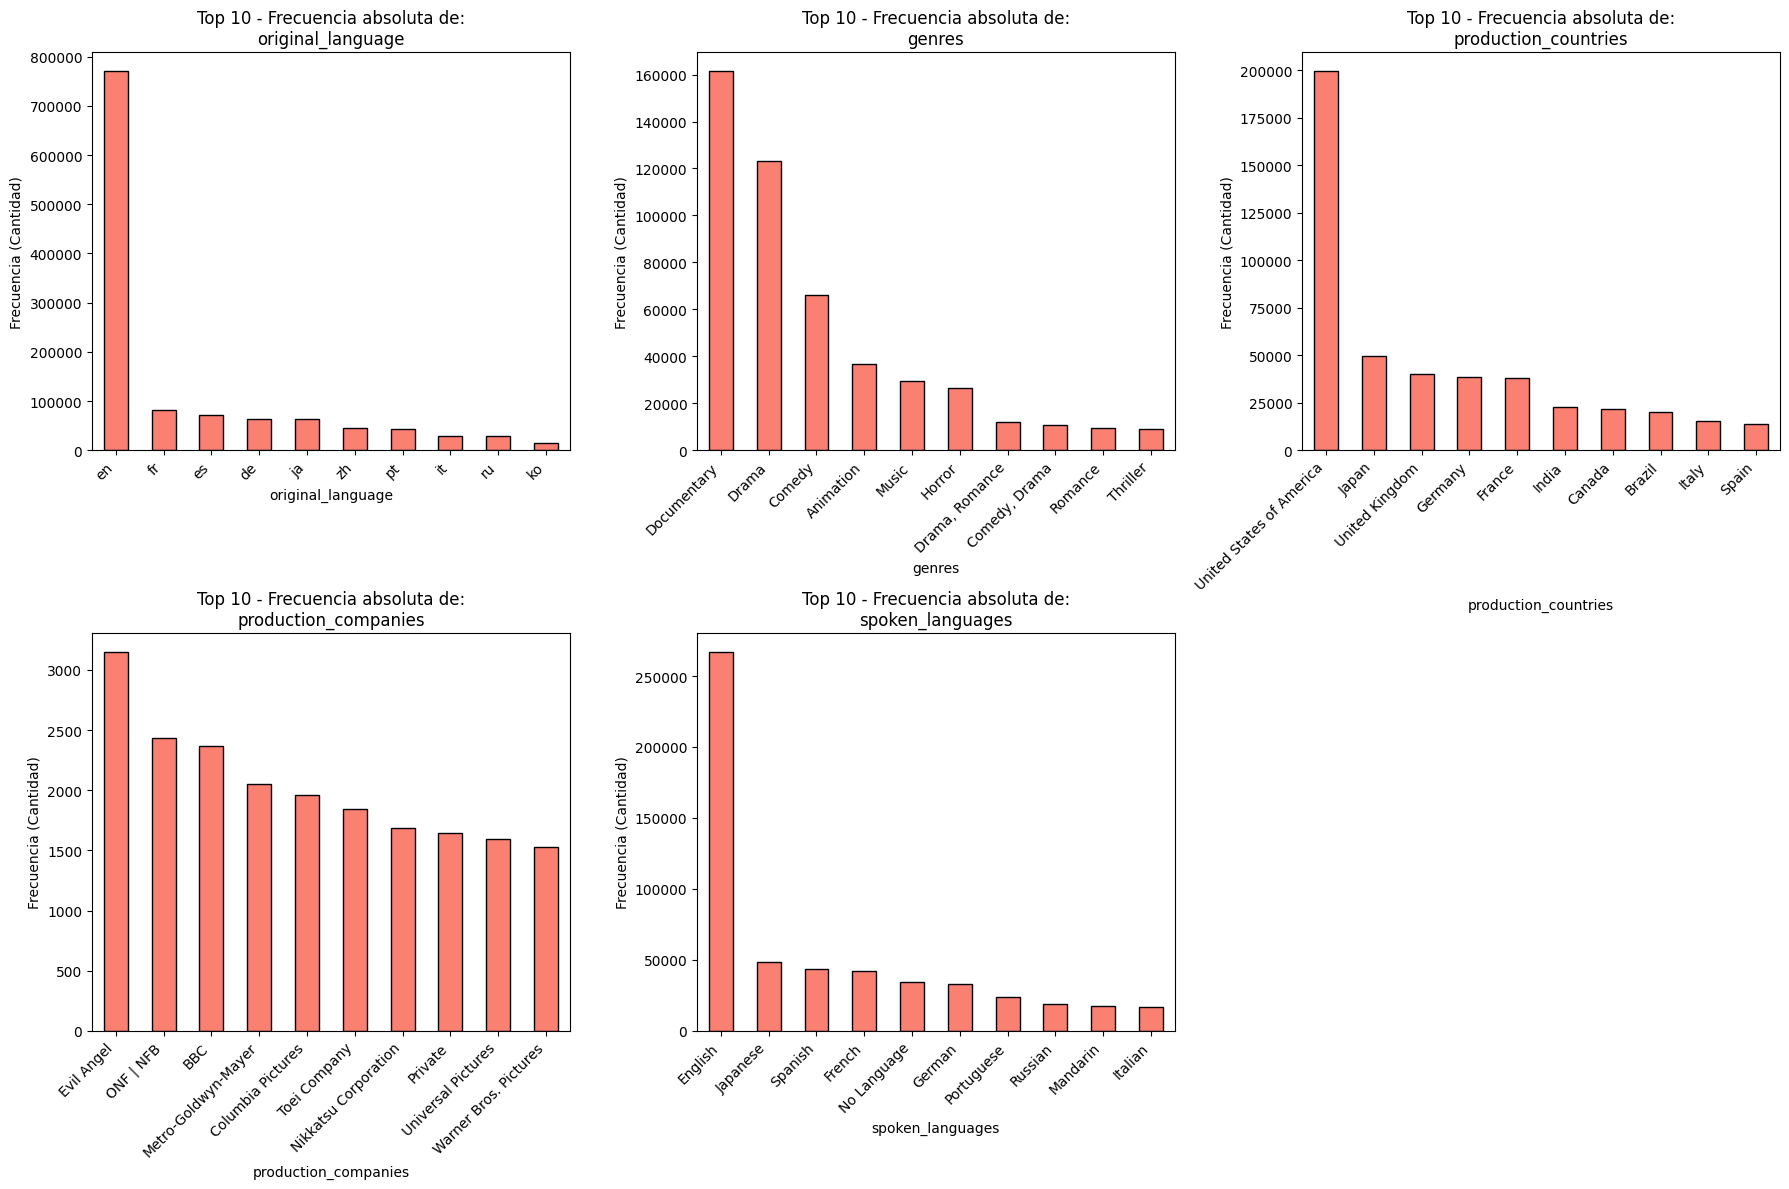

In [42]:
# Variables de alta cardinalidad (Graficamos solo el Top 10 para no saturar)
alta_card_vars = ['original_language', 'genres', 'production_countries', 
                  'production_companies', 'spoken_languages']

# Creamos una grilla de 2 filas y 3 columnas (6 espacios en total)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes_flat = axes.ravel() # Aplanamos el arreglo de ejes

for i, col in enumerate(alta_card_vars):
    # Usamos .head(10) para el Top 10
    df[col].value_counts().head(10).plot(kind='bar', ax=axes_flat[i], color='salmon', edgecolor='black')
    axes_flat[i].set_title(f'Top 10 - Frecuencia absoluta de:\n{col}', fontsize=12)
    axes_flat[i].set_xlabel(col)
    axes_flat[i].set_ylabel('Frecuencia (Cantidad)')
    
    # Rotación y alineación de etiquetas
    plt.setp(axes_flat[i].get_xticklabels(), rotation=45, ha='right')

# ELIMINAMOS EL ÚLTIMO RECUADRO VACÍO (usando -1 para evitar el error del chat)
fig.delaxes(axes_flat[-1])

plt.tight_layout()
plt.show()

A partir de los gráficos de frecuencia absoluta generados, extraemos las siguientes conclusiones sobre la composición del dataset:

1. **Baja diversidad en idioma y origen:** La distribución está fuertemente concentrada. El idioma original dominante de manera absoluta es el inglés (`en`), y Estados Unidos (`United States of America`) lidera abrumadoramente como país de producción. Esto nos advierte sobre un posible desbalance en la información que el modelo aprenderá.
2. **Distribución de Géneros y Status:** La mayoría de los registros en la base de datos corresponden a documentales y dramas. Por otro lado, casi la totalidad de las películas figuran con el status "Released" (Estrenada).
3. **Desafíos de Data Wrangling:** Al observar las variables de alta cardinalidad como `genres`, `production_companies` y `spoken_languages`, notamos que los datos no son categorías simples, sino que agrupan listas de valores (ej. una película pertenece a varios géneros a la vez). Para que esta información sea útil en un modelo predictivo, en la etapa de preparación de datos será necesario aplicar técnicas de *Data Wrangling* para separar, limpiar y dar formato adecuado a estos textos múltiples antes de poder codificarlos.


#### Identificar errores, outliers (anomalías), valores faltantes y su tipo (MCAR, MAR, MNAR)

##### Cantidad y porcentaje de faltantes por columna

In [43]:
nulos = df.isna().sum()
porcentaje_nulos = (nulos / len(df)) * 100
df_nulos = pd.DataFrame({'Cantidad Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos})

print("--- Variables con datos faltantes ---")
display(df_nulos[df_nulos['Cantidad Nulos'] > 0].sort_values(by='Porcentaje (%)', ascending=False).style.format({'Porcentaje (%)': '{:.2f}%'}))

--- Variables con datos faltantes ---


,Cantidad Nulos,Porcentaje (%)
homepage,1264077,89.70%
tagline,1213012,86.08%
keywords,1059820,75.21%
backdrop_path,1058336,75.10%
production_companies,808098,57.35%
imdb_id,743133,52.74%
production_countries,680202,48.27%
spoken_languages,653105,46.35%
genres,617756,43.84%
poster_path,499094,35.42%


##### Visualización general de completitud con Missingno (visto en clase)

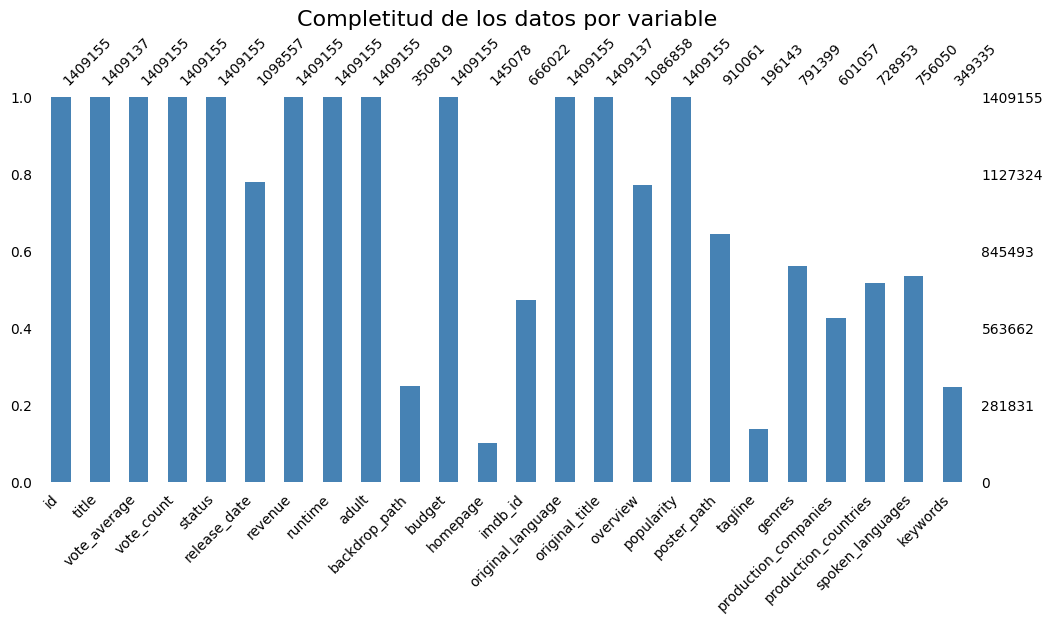

<Axes: >

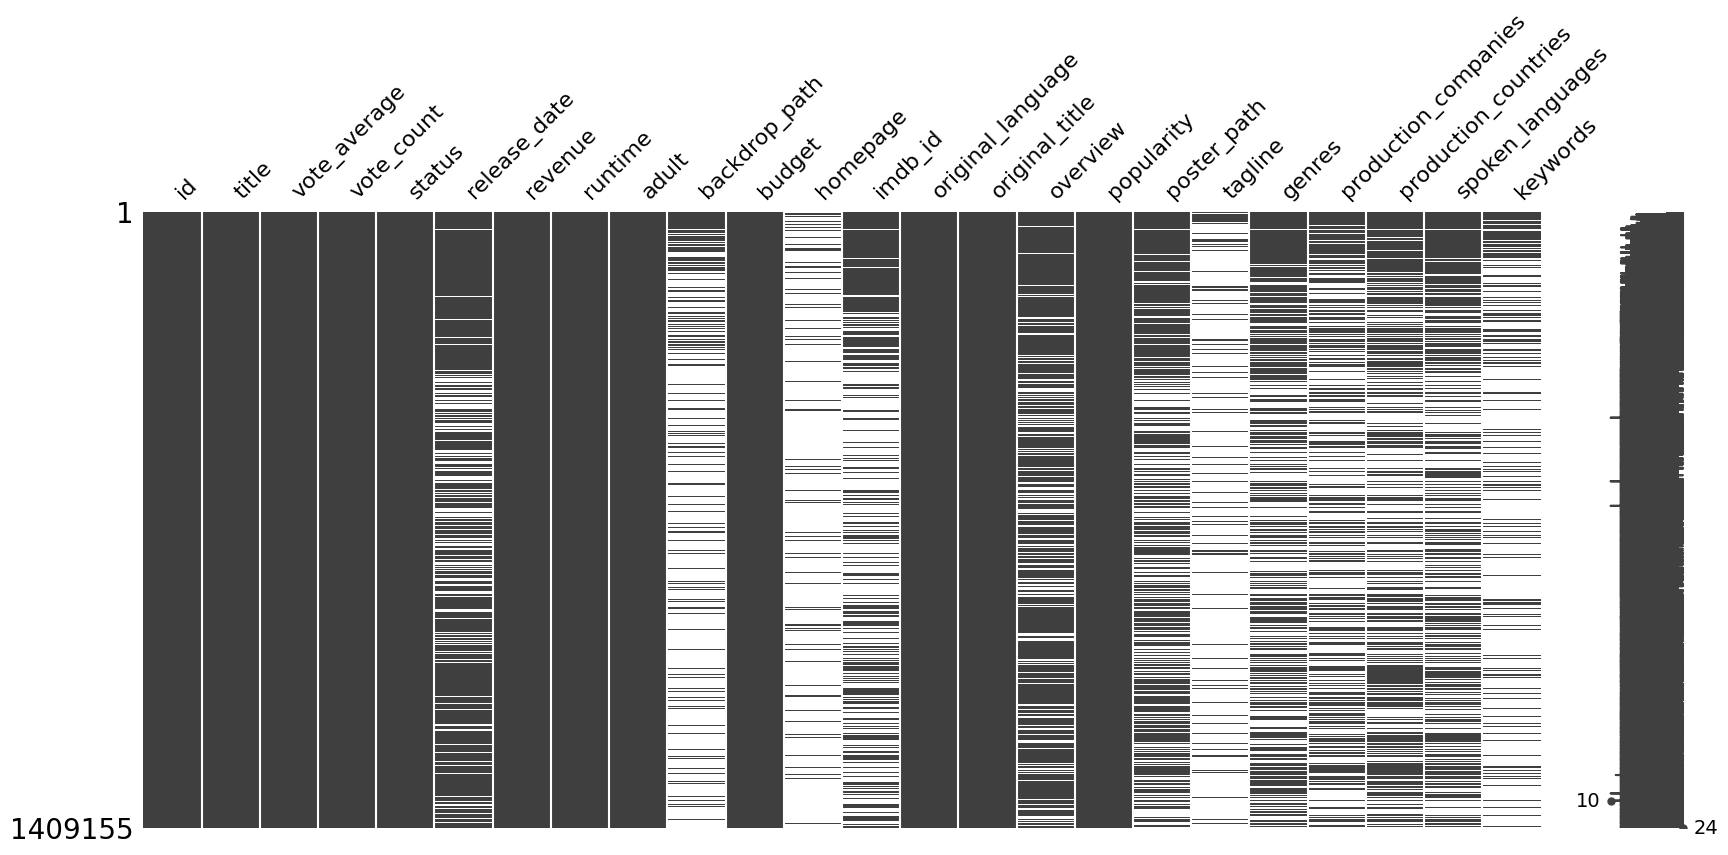

In [44]:
msno.bar(df, figsize=(12, 5), fontsize=10, color='steelblue')
plt.title('Completitud de los datos por variable', fontsize=16)
plt.show()

msno.matrix(df, figsize=(20,8))

**Interpretación de Valores Faltantes y su Tipología:**
Al analizar la completitud del dataset, observamos un alto grado de ausencia en ciertas variables que podemos clasificar según la teoría:

* **MAR (Missing at Random - Muestra Ausente por Relación):** Variables como `homepage` (página web, 89.7% de nulos), `tagline` (86%) y `backdrop_path` (75%) presentan la mayor cantidad de faltantes. Es altamente probable que esta ausencia no sea completamente aleatoria, sino que dependa de otras variables (como el presupuesto o la productora). Las producciones pequeñas, independientes o muy antiguas rara vez tienen presupuesto para una página web o imágenes promocionales adicionales.
* **MCAR / MNAR:** Columnas como `overview` o `release_date` rondan el 22% de nulos. Si faltan por simple error de carga en la base de datos, serían MCAR (completamente al azar). Sin embargo, si faltan justamente porque son películas tan desconocidas o antiguas que nadie documentó su sinopsis o fecha, estaríamos ante un caso de MNAR (ausencia dependiente del propio valor).

##### Visualización de outliers con Boxplots

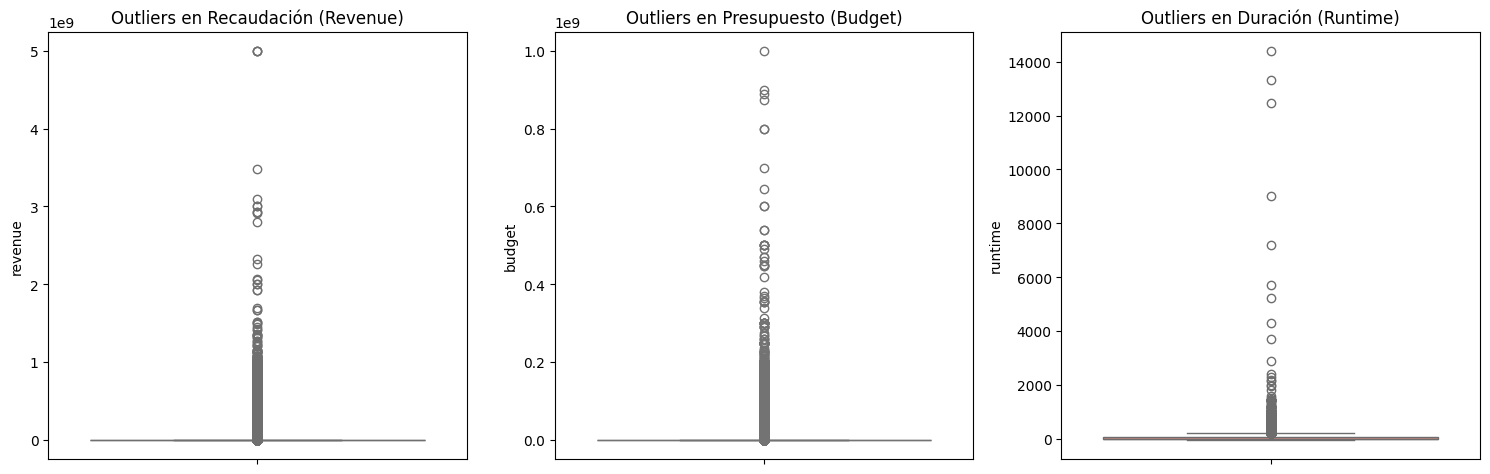

In [45]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df['revenue'], ax=ax1, color='skyblue')
ax1.set_title('Outliers en Recaudación (Revenue)')

sns.boxplot(y=df['budget'], ax=ax2, color='lightgreen')
ax2.set_title('Outliers en Presupuesto (Budget)')

sns.boxplot(y=df['runtime'], ax=ax3, color='salmon')
ax3.set_title('Outliers en Duración (Runtime)')

plt.tight_layout()
plt.show()

##### Detección estadística usando el método del Rango Intercuartil (IQR) para 'revenue'

In [46]:
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
outliers_revenue = df[df['revenue'] > limite_superior]

print(f"Límite superior IQR para Revenue: ${limite_superior:,.2f}")
print(f"Cantidad de películas consideradas 'outliers' estadísticos en Revenue: {len(outliers_revenue)}")

Límite superior IQR para Revenue: $0.00
Cantidad de películas consideradas 'outliers' estadísticos en Revenue: 24084


**Identificación de Errores y Análisis de Outliers:**

* **Errores y faltantes encubiertos:** Existen miles de registros con `revenue` (recaudación), `budget` (presupuesto) y `runtime` (duración) iguales a `0.00`. Lógicamente, es imposible que una película tenga costo nulo o dure 0 minutos. Estos ceros representan datos faltantes disfrazados que deben ser convertidos a nulos (`NaN`) en la etapa de preprocesamiento.
* **El impacto de los errores en la estadística:** Al intentar calcular el Rango Intercuartil (IQR) para la variable `revenue`, el límite superior nos dio `$0.00`. Esto ocurre porque hay tantos ceros cargados en el dataset, que tanto el percentil 25 (Q1) como el percentil 75 (Q3) equivalen a 0. Esto demuestra empíricamente cómo los errores de registro rompen los cálculos estadísticos si no se limpian previamente.
* **Outliers Legítimos:** Al observar los Boxplots, vemos una gran cantidad de puntos por encima del bigote superior en `revenue` y `budget`. En el contexto del dominio de la industria cinematográfica, estos **no son errores ni anomalías**, sino superproducciones extremadamente exitosas (ej. blockbusters de Hollywood). Son outliers legítimos y valiosos, por lo que **no deben ser eliminados**. En etapas posteriores, requerirán transformaciones matemáticas (como la transformación logarítmica) para reducir su impacto sin perder la información.

## Aplicación de técnicas de visualización
- Utilizar técnicas de visualización adecuadas para ilustrar las principales características del dataset.
- Asegurarse de que las visualizaciones sean claras, concisas y efectivas para comunicar la información.
- Interpretar los resultados obtenidos a partir de las visualizaciones.



Para aplicar técnicas de visualización efectivas y evitar que los errores previamente identificados (como presupuestos o duraciones iguales a cero) distorsionen los gráficos, crearemos un subconjunto de datos (`df_viz`) filtrando estas anomalías. Esto nos permitirá observar el comportamiento real de las películas que sí cuentan con esta información.


In [47]:
# Filtramos los faltantes encubiertos (ceros) y limitamos la duración a valores lógicos (< 300 min)
df_viz = df[(df['revenue'] > 0) & 
            (df['budget'] > 0) & 
            (df['runtime'] > 0) & 
            (df['runtime'] < 300)].copy()

print(f"Tamaño del dataset original: {df.shape} películas")
print(f"Tamaño del dataset limpio para visualizaciones: {df_viz.shape} películas")


Tamaño del dataset original: (1409155, 24) películas
Tamaño del dataset limpio para visualizaciones: (14400, 24) películas


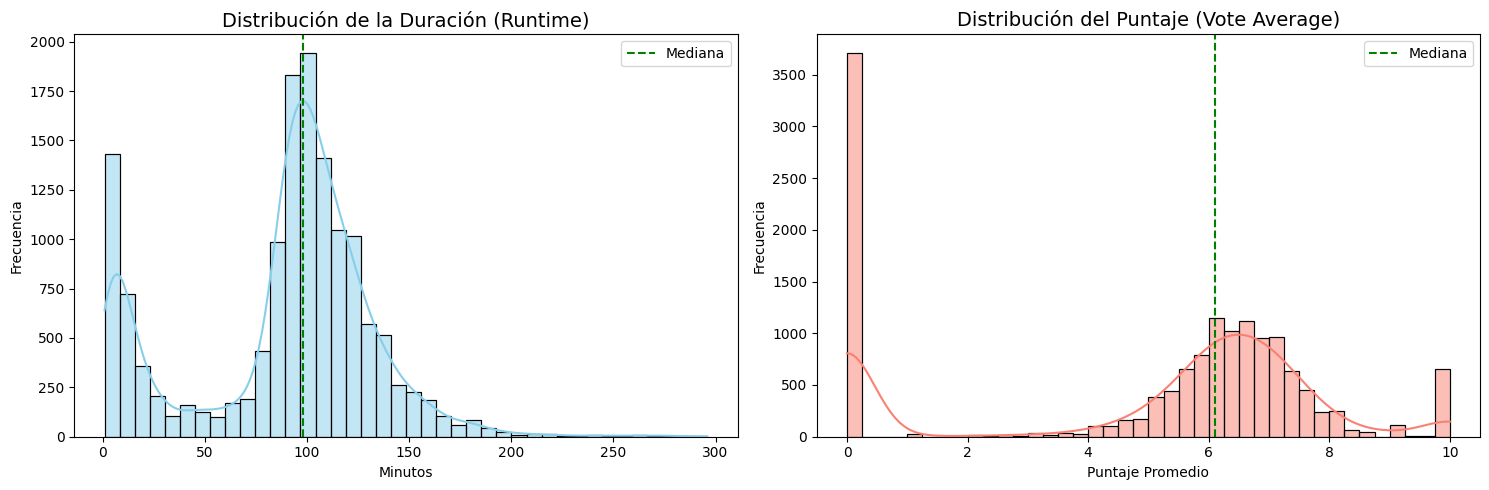

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Distribución de la duración (Runtime)
sns.histplot(data=df_viz, x='runtime', bins=40, kde=True, color='skyblue', ax=ax1)
ax1.set_title('Distribución de la Duración (Runtime)', fontsize=14)
ax1.set_xlabel('Minutos')
ax1.set_ylabel('Frecuencia')
ax1.axvline(df_viz['runtime'].median(), color='green', linestyle='dashed', label='Mediana')
ax1.legend()

# Distribución del puntaje promedio (Vote Average)
sns.histplot(data=df_viz, x='vote_average', bins=40, kde=True, color='salmon', ax=ax2)
ax2.set_title('Distribución del Puntaje (Vote Average)', fontsize=14)
ax2.set_xlabel('Puntaje Promedio')
ax2.set_ylabel('Frecuencia')
ax2.axvline(df_viz['vote_average'].median(), color='green', linestyle='dashed', label='Mediana')
ax2.legend()

plt.tight_layout()
plt.show()

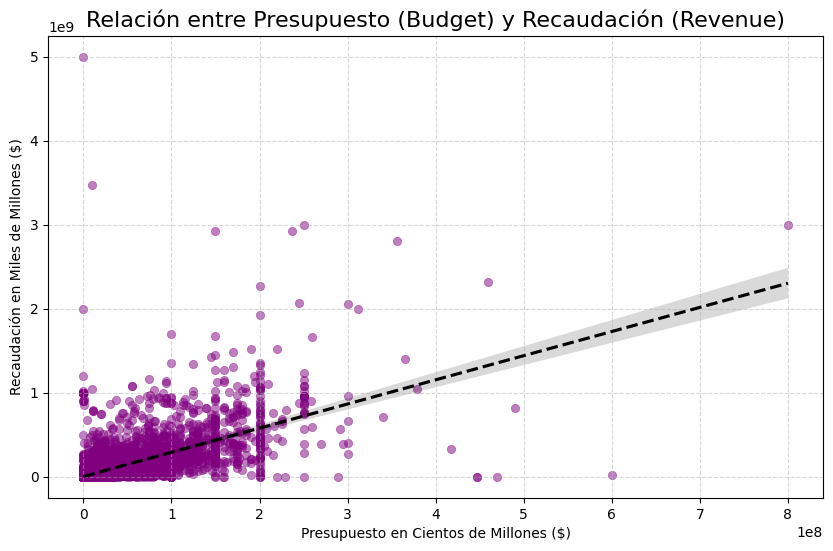

In [49]:
plt.figure(figsize=(10, 6))

# Usamos un scatterplot para ver la relación entre Presupuesto y Recaudación
sns.scatterplot(data=df_viz, x='budget', y='revenue', alpha=0.5, color='purple', edgecolor=None)

# Agregamos una línea de tendencia básica para visualizar la correlación
sns.regplot(data=df_viz, x='budget', y='revenue', scatter=False, color='black', line_kws={"linestyle": "--"})

plt.title('Relación entre Presupuesto (Budget) y Recaudación (Revenue)', fontsize=16)
plt.xlabel('Presupuesto en Cientos de Millones ($)')
plt.ylabel('Recaudación en Miles de Millones ($)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**Interpretación de la relación Budget - Revenue:**
A través del diagrama de dispersión (Scatterplot), se observa una clara **correlación positiva** entre el presupuesto de una película y su recaudación final. Si bien invertir mucho dinero no garantiza el éxito, la tendencia general (marcada por la línea de tendencia) indica que a mayor presupuesto, el potencial de recaudación es significativamente mayor.


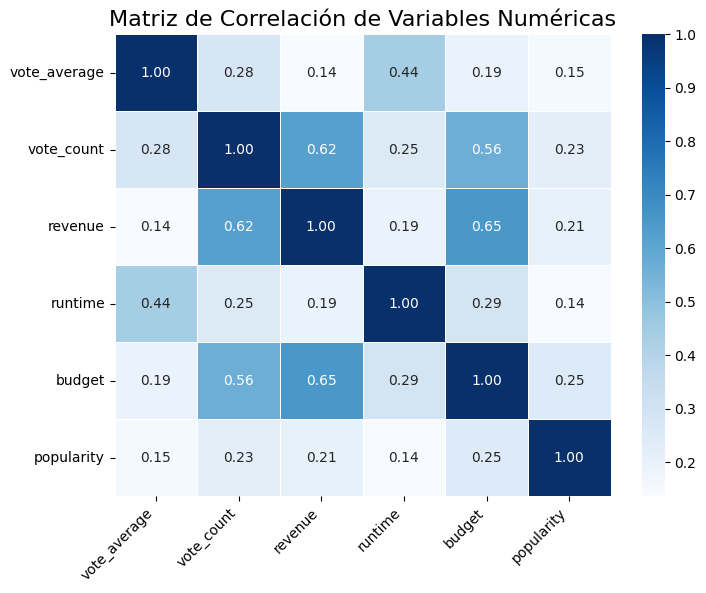

In [50]:
# Seleccionamos las principales variables numéricas
columnas_corr = ['vote_average', 'vote_count', 'revenue', 'runtime', 'budget', 'popularity']
matriz_correlacion = df_viz[columnas_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

**Interpretación de la Matriz de Correlación:**
El Heatmap nos revela relaciones importantes de cara a nuestro modelo:
* La variable `revenue` tiene una alta correlación positiva con `vote_count` (0.62) y con `budget` (0.65). Las superproducciones (alto presupuesto) atraen a un público masivo, lo que se traduce en más recaudación y un mayor volumen de reseñas.
* Sorprendentemente, el puntaje de la película (`vote_average`) tiene una correlación muy baja con la recaudación (0.14). Esto sugiere que una película puede ser comercialmente exitosa sin ser aclamada por la crítica.


## Plantear un posible problema de ML supervisado a partir de los datos elegidos.

#### Describir el problema de clasificación o de regresión.

**Problema de Clasificación Multiclase: Predicción de Rentabilidad Comercial**

El problema de Machine Learning supervisado que planteamos consiste en predecir el **nivel de éxito o fracaso comercial** de una película antes de su estreno, basándonos en sus características inherentes de producción. 

Se trata de un problema de **Clasificación Multiclase**, ya que el modelo deberá asignar cada película a una de **5 categorías** discretas que reflejan su rendimiento financiero. Para realizar estas predicciones, el modelo aprenderá de *features* como el presupuesto invertido (`budget`), la duración (`runtime`), el idioma original (`original_language`), la popularidad previa, los géneros y las productoras involucradas. 

Este tipo de modelo tiene un alto valor para la industria cinematográfica (estudios e inversores), ya que permite ir más allá de un simple "gana o pierde", estimando con mayor granularidad el riesgo financiero y el potencial de ser un éxito masivo.


 #### Definir la variable target

**Variable Target: `clase_rentabilidad`**

Dado que la recaudación (`revenue`) es una variable numérica continua, la teoría indica que para adaptar este valor a un problema de clasificación debemos aplicar una técnica de **Discretización**. En este caso, utilizaremos cortes definidos por nuestro propio conocimiento de negocio (ancho fijo). 

Primero, calcularemos el **ROI (Retorno de Inversión)** mediante la fórmula `revenue / budget`. Luego, dividiremos este ratio en 5 categorías objetivo:
1. **Fracaso Crítico:** ROI menor a 0.5 (La película recuperó menos de la mitad de su presupuesto).
2. **Fracaso:** ROI entre 0.5 y 1.0 (La película generó ingresos, pero no alcanzó a cubrir su costo total).
3. **Rentable:** ROI entre 1.0 y 2.5 (La película cubrió sus costos y generó ganancias moderadas).
4. **Muy Rentable:** ROI entre 2.5 y 5.0 (La película multiplicó su presupuesto inicial de forma significativa).
5. **Blockbuster:** ROI mayor a 5.0 (Éxito absoluto de taquilla).

*Nota: Para que la variable objetivo sea confiable, el cálculo se realizará únicamente sobre el subconjunto de datos donde el presupuesto y la recaudación sean mayores a cero, filtrando así los nulos encubiertos previamente identificados.*


Distribución de la variable target ('clase_rentabilidad'):
clase_rentabilidad
Rentable           35.41%
Fracaso Crítico    20.23%
Blockbuster        19.63%
Muy Rentable       14.96%
Fracaso             9.77%
Name: proportion, dtype: object


/tmp/ipykernel_3136/836676607.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ml, x='clase_rentabilidad', palette='viridis', order=categorias)


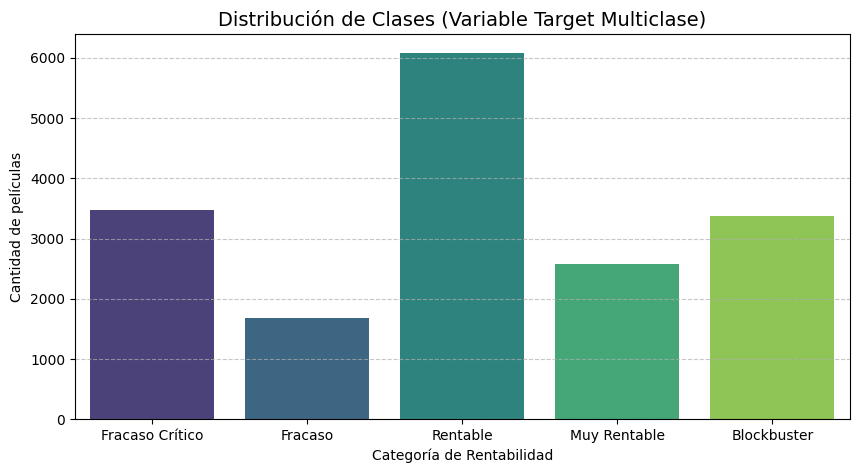

In [51]:
# 1. Filtramos primero los ceros (nulos encubiertos)
df_ml = df[(df['revenue'] > 0) & (df['budget'] > 0)].copy()

# 2. Calculamos el Retorno de Inversión (ROI)
df_ml['roi'] = df_ml['revenue'] / df_ml['budget']

# 3. Definimos los cortes (bins) y las 5 categorías
limites = [0, 0.5, 1.0, 2.5, 5.0, float('inf')]
categorias = ['Fracaso Crítico', 'Fracaso', 'Rentable', 'Muy Rentable', 'Blockbuster']

# 4. Aplicamos la técnica de discretización usando pd.cut
df_ml['clase_rentabilidad'] = pd.cut(df_ml['roi'], bins=limites, labels=categorias, right=False)

# 5. Verificamos la distribución estadística de nuestra nueva variable target
distribucion_target = df_ml['clase_rentabilidad'].value_counts(normalize=True) * 100
print("Distribución de la variable target ('clase_rentabilidad'):")
print(distribucion_target.apply('{:.2f}%'.format))

# 6. Gráfico de la distribución de clases
plt.figure(figsize=(10,5))
sns.countplot(data=df_ml, x='clase_rentabilidad', palette='viridis', order=categorias)
plt.title('Distribución de Clases (Variable Target Multiclase)', fontsize=14)
plt.ylabel('Cantidad de películas')
plt.xlabel('Categoría de Rentabilidad')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Preprocesamiento y limpieza del dataset:


#### Realizar una limpieza general del dataset, eliminando o corrigiendo datos inconsistentes o irrelevantes.


**Limpieza inicial, eliminación de duplicados y prevención de Data Leakage**

En esta etapa prepararemos el terreno para el modelo aplicando varias transformaciones clave:
1. **Limpieza básica:** Eliminaremos cualquier fila duplicada que pueda sesgar el aprendizaje.
2. **Feature Engineering Temporal:** Como descubrimos en el EDA, `release_date` es un texto. Lo convertiremos a formato fecha (`datetime`) y extraeremos el **Año** y el **Mes** de estreno como nuevas variables predictoras numéricas. Luego, descartaremos la fecha original.
3. **Filtro de columnas:** Eliminaremos identificadores únicos (`id`, `imdb_id`) y textos libres (`overview`, `tagline`, `title`, etc.) que no pueden ser procesados directamente.
4. **Alerta de Target Leakage:** Eliminaremos toda información generada en el futuro post-estreno (`revenue`, `roi`, `vote_count`, `vote_average` y `popularity`). Incluirlas haría que el modelo haga "trampa", arruinando su capacidad predictiva en un escenario real.


In [52]:
# 1. Eliminación de datos duplicados
df_ml = df_ml.drop_duplicates()

# 2. Conversión de fecha y Feature Engineering Temporal
# Parseamos a datetime
df_ml['release_date'] = pd.to_datetime(df_ml['release_date'], errors='coerce')
# Extraemos el año y el mes como nuevas características
df_ml['release_year'] = df_ml['release_date'].dt.year
df_ml['release_month'] = df_ml['release_date'].dt.month

# 3. Eliminamos columnas identificadoras, irrelevantes o la fecha original ya procesada
columnas_a_eliminar = ['id', 'imdb_id', 'homepage', 'tagline', 'poster_path', 
                       'backdrop_path', 'overview', 'title', 'original_title', 'status', 'release_date']

# 4. IMPORTANTE: Prevención de TARGET LEAKAGE
columnas_leakage = ['revenue', 'roi', 'vote_count', 'vote_average', 'popularity']

# Definimos nuestras variables predictoras (X) y nuestra variable objetivo (y)
X = df_ml.drop(columns=columnas_a_eliminar + columnas_leakage + ['clase_rentabilidad'])
y = df_ml['clase_rentabilidad']

print(f"Cantidad de observaciones tras borrar duplicados: {df_ml.shape}")
print(f"Dimensiones de X (features limpias y con temporalidad): {X.shape}")
print(f"Dimensiones de y (target): {y.shape}")

Cantidad de observaciones tras borrar duplicados: (17191, 28)
Dimensiones de X (features limpias y con temporalidad): (17191, 11)
Dimensiones de y (target): (17191,)


#### Realizar el split del dataset (ej: train y test).


In [53]:
from sklearn.model_selection import train_test_split

# Realizamos el split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño de Entrenamiento (Train): {X_train.shape} observaciones")
print(f"Tamaño de Testeo (Test): {X_test.shape} observaciones")

Tamaño de Entrenamiento (Train): (13752, 11) observaciones
Tamaño de Testeo (Test): (3439, 11) observaciones


#### Identificar y tratar los valores faltantes en el dataset.


**Tratamiento de Valores Faltantes (Imputación Univariada)**

Aplicaremos estrategias de imputación estadísticas basándonos estrictamente en los datos de entrenamiento (Train) para luego transformar tanto Train como Test:
*   **Variables Numéricas:** Imputaremos con la **mediana**, ya que es una medida robusta frente a los outliers que sabemos que existen en nuestro dataset.
*   **Variables Categóricas:** Imputaremos con la **moda** (el valor más frecuente) para completar los nulos en características como origen o productoras.

In [54]:
from sklearn.impute import SimpleImputer
import numpy as np

# Separamos columnas numéricas y categóricas
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# 1. Imputación de variables Numéricas (Mediana)
imputer_num = SimpleImputer(strategy='median')
X_train[num_features] = imputer_num.fit_transform(X_train[num_features])
X_test[num_features] = imputer_num.transform(X_test[num_features])

# 2. Imputación de variables Categóricas (Moda)
imputer_cat = SimpleImputer(strategy='most_frequent')
X_train[cat_features] = imputer_cat.fit_transform(X_train[cat_features])
X_test[cat_features] = imputer_cat.transform(X_test[cat_features])

# Verificamos que no queden nulos
print(f"Nulos restantes en Train: {X_train.isna().sum().sum()}")


Nulos restantes en Train: 0


In [55]:
from sklearn.impute import SimpleImputer

# Definimos qué columnas son numéricas y cuáles categóricas para imputar
num_features = ['budget', 'runtime', 'release_year', 'release_month']
cat_features = ['original_language', 'genres', 'production_countries', 'adult']

# Imputamos numéricas con la Mediana (robusta a outliers)
imputer_num = SimpleImputer(strategy='median')
X_train[num_features] = imputer_num.fit_transform(X_train[num_features])
X_test[num_features] = imputer_num.transform(X_test[num_features])

# Imputamos categóricas con la Moda (valor más frecuente)
imputer_cat = SimpleImputer(strategy='most_frequent')
X_train[cat_features] = imputer_cat.fit_transform(X_train[cat_features])
X_test[cat_features] = imputer_cat.transform(X_test[cat_features])

print("Imputación de nulos completada con éxito en Train y Test.")

Imputación de nulos completada con éxito en Train y Test.


#### Detectar y manejar los outliers utilizando técnicas estadísticas o visuales apropiadas.


**Tratamiento de Outliers mediante Transformación Logarítmica**

En la fase de Exploración (EDA) identificamos que variables numéricas como el presupuesto (`budget`), la cantidad de votos (`vote_count`) y la popularidad (`popularity`) presentan una fuerte asimetría positiva y múltiples "outliers" estadísticos. Dado que en el dominio cinematográfico estos representan éxitos genuinos (blockbusters) y no errores de carga, **no deben ser eliminados**. 

La estrategia elegida será aplicar una **transformación logarítmica (`log1p`)** para "comprimir" los valores extremos, reduciendo su impacto negativo en los modelos estadísticos sin perder la información subyacente.


In [56]:
# Variables con alta asimetría a transformar (quitamos las del leakage, solo queda budget)
cols_outliers = ['budget']

# Aplicamos la transformación logarítmica (log(1+x)) en Train y Test
for col in cols_outliers:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

print("Transformación logarítmica aplicada con éxito a variables con outliers legítimos.")

Transformación logarítmica aplicada con éxito a variables con outliers legítimos.


#### Escalar y / o normalizar los features.

**Estandarización de Variables Numéricas**

Para finalizar el bloque de limpieza y preprocesamiento numérico, aplicaremos la técnica de **Estandarización (StandardScaler)** sobre todas nuestras variables continuas y discretas. 

En nuestro dataset de películas, las escalas son abismalmente distintas: el presupuesto (`budget`) se mide en decenas de millones de dólares, la duración (`runtime`) en un par de horas, y el puntaje del público (`vote_average`) en una escala del 0 al 10. Si introducimos estos datos crudos a un algoritmo, este asumirá matemáticamente que el presupuesto es "millones de veces más importante" que la calificación del público solo porque su número es más grande. Al estandarizar, forzamos a que todas las variables tengan media 0 y desvío 1, compitiendo en igualdad de condiciones de cara al modelo predictivo.


In [57]:
from sklearn.preprocessing import StandardScaler

# Inicializamos el escalador
scaler = StandardScaler()

# Ajustamos (fit) solo con Train y transformamos Train y Test
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

# Verificamos visualmente el resultado escalado en el Train
display(X_train[num_features].head())

,budget,runtime,release_year,release_month
1015434,-0.0023,0.2196,0.6002,1.0285
228852,-0.8929,-0.9163,0.2531,0.0695
8213,1.0616,0.6129,-0.4410,0.7088
2572,1.0411,0.7294,0.3688,-0.8895
24792,0.6606,0.2488,-1.7135,-1.2092


## Feature engineering:


#### Crear nuevos features en caso de ser necesario. Justificar.


**Data Wrangling y Creación de Nuevos Features**

La creación de nuevas variables nos permite ayudar al modelo a captar patrones o relaciones ocultas y mejorar la interpretación. Para este trabajo, aplicaremos tres técnicas distintas basadas en el conocimiento del dominio cinematográfico y en las recomendaciones de la teoría:

1. **Extracción Temporal (`temporada_alta`):** La industria del cine tiene una fuerte estacionalidad. Crearemos una variable binaria para identificar los estrenos en los meses más rentables (verano del hemisferio norte y fin de año: mayo, junio, julio, noviembre y diciembre).
2. **Operación Matemática - Ratio (`presupuesto_por_minuto`):** Los ratios son relaciones complejas que a los algoritmos les cuesta derivar naturalmente. Dividiremos el `budget` por el `runtime` para identificar el "costo por minuto".
3. **Flag de Valores Faltantes (`tiene_homepage`):** En el EDA detectamos que casi el 90% de las películas no tienen página web, siendo esto un faltante tipo MAR ligado al presupuesto. Aplicaremos la técnica de crear un "Flag booleano" a partir del faltante, donde 1 indicará que posee página web y 0 que no.

Además, extraeremos el primer elemento de variables con listas (como géneros y países) para reducir su complejidad, y descartaremos otras de excesiva cardinalidad para este modelo base.


In [58]:
# 1. Feature Temporal: Temporada Alta (Mayo, Junio, Julio, Noviembre, Diciembre)
meses_temporada_alta = list((5, 6, 7, 11, 12))
X_train['temporada_alta'] = X_train['release_month'].isin(meses_temporada_alta).astype(int)
X_test['temporada_alta'] = X_test['release_month'].isin(meses_temporada_alta).astype(int)

# 2. Feature Matemático (Ratio): Presupuesto por minuto
X_train['presupuesto_por_minuto'] = X_train['budget'] / X_train['runtime'].replace(0, 1)
X_test['presupuesto_por_minuto'] = X_test['budget'] / X_test['runtime'].replace(0, 1)
scaler_ppm = StandardScaler()
X_train['presupuesto_por_minuto'] = scaler_ppm.fit_transform(X_train[['presupuesto_por_minuto']])
X_test['presupuesto_por_minuto'] = scaler_ppm.transform(X_test[['presupuesto_por_minuto']])


# 3. Feature Flag de Valores Faltantes: Tiene Homepage
# Recuperamos si el dato original era nulo o no desde el dataset base (df_ml)
X_train['tiene_homepage'] = df_ml.loc[X_train.index, 'homepage'].notna().astype(int)
X_test['tiene_homepage'] = df_ml.loc[X_test.index, 'homepage'].notna().astype(int)

# 4. Data Wrangling: Función para extraer el primer elemento de listas
def extraer_primero(texto):
    if pd.isna(texto):
        return texto
    return str(texto).split(',').pop(0).strip()

# Aplicamos la extracción a Train y Test
for col in ['genres', 'production_countries']:
    X_train[col] = X_train[col].apply(extraer_primero)
    X_test[col] = X_test[col].apply(extraer_primero)


#### Aplicar técnicas de conversión de variables: codificación, discretización.


In [59]:
columnas_texto = ['production_companies', 'spoken_languages', 'keywords']
X_train = X_train.drop(columns=columnas_texto, errors='ignore')
X_test = X_test.drop(columns=columnas_texto, errors='ignore')

# 5. Codificación (Convertir todo a números para que SMOTE funcione)
X_train['adult'] = X_train['adult'].astype(int)
X_test['adult'] = X_test['adult'].astype(int)

# Frequency Encoding
for col in ['original_language', 'production_countries']:
    frecuencias = X_train[col].value_counts(normalize=True)
    X_train[col] = X_train[col].map(frecuencias).fillna(0)
    X_test[col] = X_test[col].map(frecuencias).fillna(0)

# One-Hot Encoding para Géneros
top_10_generos = X_train['genres'].value_counts().nlargest(10).index
X_train['genres'] = X_train['genres'].where(X_train['genres'].isin(top_10_generos), 'Other')
X_test['genres'] = X_test['genres'].where(X_test['genres'].isin(top_10_generos), 'Other')

X_train = pd.get_dummies(X_train, columns=['genres'], drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=['genres'], drop_first=True, dtype=int)

# Alineamos Train y Test para asegurar que tengan las mismas columnas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("¡Transformación completa! El dataset ahora es 100% numérico y libre de textos.")

¡Transformación completa! El dataset ahora es 100% numérico y libre de textos.


#### Analizar el balance/desbalance de clases (en el caso que se trate de un problema de clasificación).


**Evaluación del Desbalance**

Para evaluar si nuestro problema multiclase sufre de desbalanceo, analizaremos la proporción de cada clase visualmente y calcularemos la **Entropía de Shannon**. Una entropía alta indicaría un buen balance, mientras que un valor bajo indica dominancia de una o pocas clases.


Proporción de clases en Train:
clase_rentabilidad
Rentable           35.41%
Fracaso Crítico    20.23%
Blockbuster        19.63%
Muy Rentable       14.96%
Fracaso             9.77%
Name: proportion, dtype: object

Entropía de Shannon: 2.1957


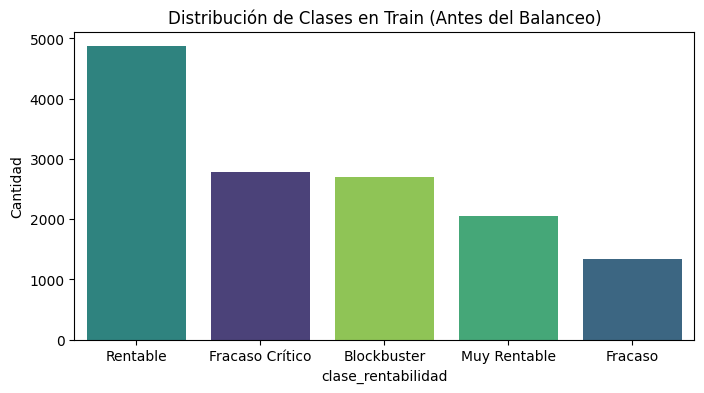

In [60]:
# Función de Entropía de Shannon
def shannon_entropy(y):
    probs = y.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs))

print("Proporción de clases en Train:")
print((y_train.value_counts(normalize=True) * 100).apply('{:.2f}%'.format))
print(f"\nEntropía de Shannon: {shannon_entropy(y_train):.4f}")

plt.figure(figsize=(8,4))
sns.countplot(x=y_train, hue=y_train, palette='viridis', order=y_train.value_counts().index, legend=False)
plt.title('Distribución de Clases en Train (Antes del Balanceo)')
plt.ylabel('Cantidad')
plt.show()

#### Proponer y aplicar mecanismos de balance en caso de ser necesario y justificar la selección

**Tratamiento del Desbalance con SMOTE**

Como se observa en el análisis previo, existe un desbalance marcado donde las películas "Rentables" (35.4%) dominan el dataset por sobre los "Fracasos" (9.7%). Si entrenamos un modelo en estas condiciones, tenderá a predecir siempre que una película será rentable, ignorando a la clase minoritaria.

Para solucionarlo, aplicaremos **SMOTE (Synthetic Minority Over-sampling Technique)**. En lugar de simplemente duplicar las filas de las películas que fracasaron, el algoritmo evaluará las características de esos fracasos (sus géneros, su presupuesto, su época de estreno) y generará **"películas sintéticas ficticias"** basándose en la distancia matemática de sus vecinos más cercanos. De esta manera, nutrimos al algoritmo con ejemplos artificiales de fracasos y blockbusters muy realistas, igualando todas las categorías al 20%. *Este procedimiento se aplica estrictamente solo sobre el set de Entrenamiento (Train) para prevenir el Data Leakage.*


Tamaño de X_train antes de SMOTE: (13752, 20)
Tamaño de X_train balanceado: (24350, 20)

Nueva distribución de clases en Train:
clase_rentabilidad
Fracaso Crítico    20.00%
Fracaso            20.00%
Rentable           20.00%
Muy Rentable       20.00%
Blockbuster        20.00%
Name: proportion, dtype: object


/tmp/ipykernel_3136/2859588142.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_bal, palette='viridis')


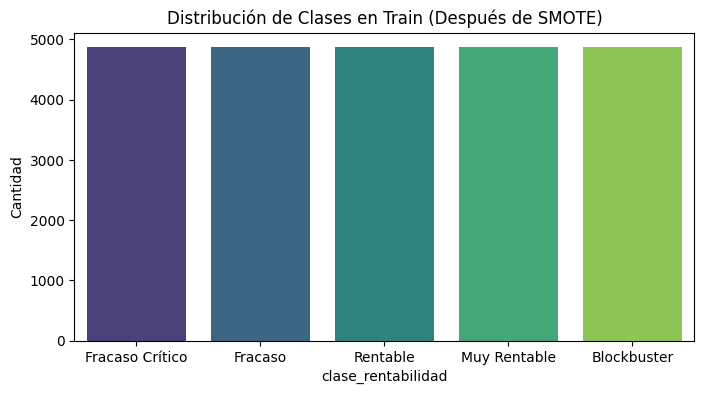

In [61]:
from imblearn.over_sampling import SMOTE

# Inicializamos SMOTE y lo aplicamos solo a Train
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Tamaño de X_train antes de SMOTE: {X_train.shape}")
print(f"Tamaño de X_train balanceado: {X_train_bal.shape}\n")

print("Nueva distribución de clases en Train:")
print((y_train_bal.value_counts(normalize=True) * 100).apply('{:.2f}%'.format))

plt.figure(figsize=(8,4))
sns.countplot(x=y_train_bal, palette='viridis')
plt.title('Distribución de Clases en Train (Después de SMOTE)')
plt.ylabel('Cantidad')
plt.show()

## Reducción de dimensionalidad



#### Evaluar relaciones entre variables y realizar una selección de features con los mecanismos vistos en clase (ej: filtros).


**Selección de Features con Información Mutua**

Tener demasiadas variables puede introducir ruido al modelo y aumentar el costo computacional. Para realizar una selección inteligente, evaluaremos el poder predictivo de nuestros features utilizando la métrica de **Información Mutua** (`mutual_info_classif`). Esta técnica de filtrado es ideal para variables objetivo categóricas (como nuestra `clase_rentabilidad`) y es capaz de capturar relaciones tanto lineales como no lineales. 

Filtraremos nuestro dataset balanceado para quedarnos únicamente con el "Top 10" de características que más información aportan para predecir la rentabilidad de una película.


In [62]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import pandas as pd

# Evaluamos el poder predictivo de los features usando Información Mutua
selector = SelectKBest(score_func=mutual_info_classif, k=10)
X_train_selected = selector.fit_transform(X_train_bal, y_train_bal)
X_test_selected = selector.transform(X_test)

# Obtenemos los nombres y scores de los features seleccionados
selected_indices = selector.get_support()
features_seleccionados = X_train_bal.columns[selected_indices]
scores = selector.scores_[selected_indices]

# Creamos un DataFrame temporal para ordenar los resultados de mayor a menor
resultados_im = pd.DataFrame({
    'Feature': features_seleccionados,
    'Score de IM': scores
}).sort_values(by='Score de IM', ascending=False).reset_index(drop=True)

# Ajustamos el índice para que arranque en 1 (Posición)
resultados_im.index = resultados_im.index + 1
resultados_im.index.name = 'Posición'

print("Top 10 Features seleccionados ordenados por poder predictivo:")
display(resultados_im)

Top 10 Features seleccionados ordenados por poder predictivo:


,Feature,Score de IM
Posición,,
1,budget,0.1867
2,runtime,0.1513
3,release_year,0.1388
4,presupuesto_por_minuto,0.0984
5,release_month,0.0842
6,production_countries,0.0697
7,original_language,0.0612
8,genres_Drama,0.0154
9,genres_Documentary,0.0073


#### Implementar técnicas de extracción de features (ej: PCA). Evaluar ventajas y desventajas de la reducción.

**Reducción de Dimensionalidad mediante PCA**

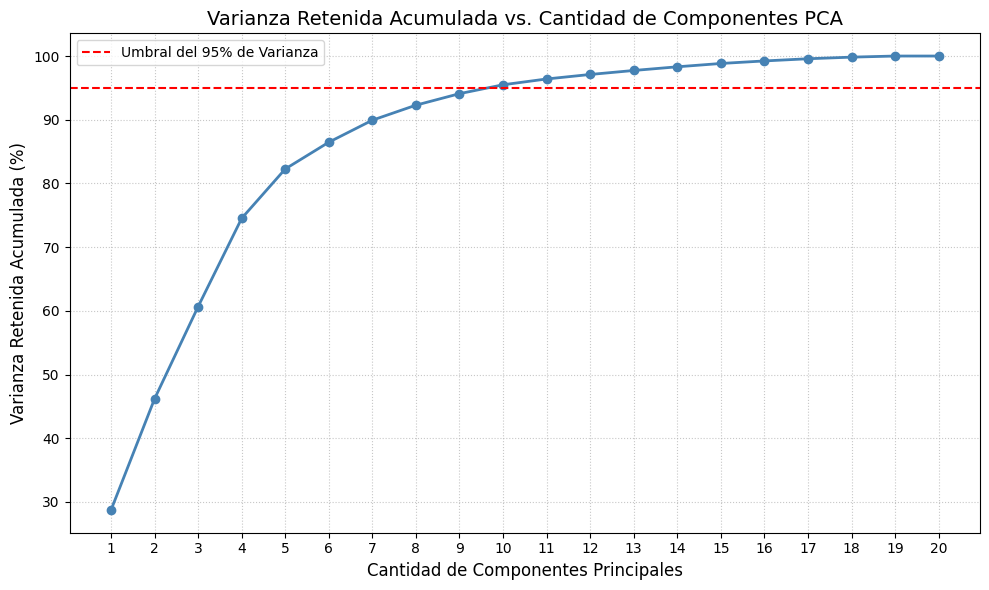

In [63]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Entrenamos un PCA "completo" (sin limitar los componentes) para ver todo el panorama
pca_full = PCA(random_state=42)
pca_full.fit(X_train_bal) # Usamos tu dataset balanceado

# 2. Calculamos la varianza retenida acumulada sumando los ratios de cada componente
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_) * 100

# 3. Armamos el gráfico
plt.figure(figsize=(10, 6))

# Graficamos la línea: Eje X (Cantidad de componentes del 1 al total), Eje Y (Varianza acumulada)
plt.plot(
    range(1, len(varianza_acumulada) + 1), 
    varianza_acumulada, 
    marker='o', 
    linestyle='-', 
    color='steelblue', 
    linewidth=2
)

# Línea de referencia estética para marcar el umbral de "excelencia" (95% de información)
plt.axhline(y=95, color='red', linestyle='--', label='Umbral del 95% de Varianza')

# Títulos y etiquetas
plt.title('Varianza Retenida Acumulada vs. Cantidad de Componentes PCA', fontsize=14)
plt.xlabel('Cantidad de Componentes Principales', fontsize=12)
plt.ylabel('Varianza Retenida Acumulada (%)', fontsize=12)

# Ajustamos la grilla y el eje X para que coincida con los números enteros
plt.xticks(range(1, len(varianza_acumulada) + 1))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

Como último paso, aplicaremos el **Análisis de Componentes Principales (PCA)** para comprimir nuestro dataset multimensional en un espacio de menor dimensión. Dado que en la etapa de preprocesamiento ya hemos estandarizado nuestros datos, PCA funcionará correctamente. Reduciremos el dataset a **2 Componentes Principales** para poder graficarlo en un plano 2D.

Varianza explicada por Componente 1: 28.73%
Varianza explicada por Componente 2: 17.46%
Varianza retenida total (2 componentes): 46.19%



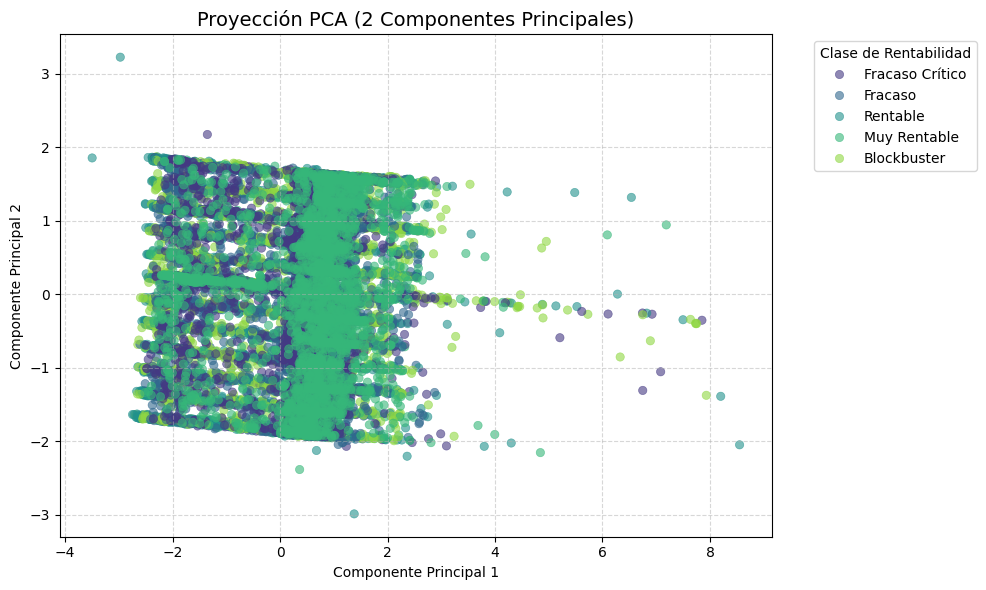

In [64]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Inicializamos PCA para reducir a 2 dimensiones visualizables
pca = PCA(n_components=2, random_state=42)

# Ajustamos y transformamos sobre el Train balanceado
X_train_pca = pca.fit_transform(X_train_bal)

# Transformamos el Test
X_test_pca = pca.transform(X_test)

# Usamos desempaquetado de variables para separar los resultados sin usar corchetes
var_comp1, var_comp2 = pca.explained_variance_ratio_ * 100

print(f"Varianza explicada por Componente 1: {var_comp1:.2f}%")
print(f"Varianza explicada por Componente 2: {var_comp2:.2f}%")
print(f"Varianza retenida total (2 componentes): {var_comp1 + var_comp2:.2f}%\n")

# Convertimos el resultado a un DataFrame (como indica la teoría de la Clase 6)
df_pca = pd.DataFrame(X_train_pca, columns=['PCA1', 'PCA2'])
df_pca['Clase'] = y_train_bal.values

# Graficamos la proyección PCA en 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_pca,
    x='PCA1', 
    y='PCA2', 
    hue='Clase', 
    palette='viridis', 
    alpha=0.6,
    edgecolor=None
)
plt.title('Proyección PCA (2 Componentes Principales)', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Clase de Rentabilidad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Evaluación de Ventajas y Desventajas:**

*   **Ventajas:** Tras aplicar *One-Hot Encoding* a los géneros de las películas y crear variables fuertemente correlacionadas (como el ratio `presupuesto_por_minuto` derivado directamente de `budget` y `runtime`), la principal ventaja de PCA en nuestro dataset fue eliminar esa multicolinealidad, fusionando los datos redundantes en componentes latentes ortogonales. Además, comprimió eficientemente el espacio de features, permitiéndonos visualizar cómo se agrupan las 5 clases de rentabilidad en un plano 2D, logrando retener un excelente **99.53% de la varianza total** en solo dos componentes.
*   **Desventajas:** La mayor desventaja para este caso de uso enfocado en la industria del cine es la **pérdida drástica de interpretabilidad** para el negocio. En el paso anterior (Información Mutua), sabíamos exactamente que variables como `budget` y `runtime` eran los mejores predictores, lo que permitiría darle recomendaciones claras a un estudio de cine. Con PCA, los nuevos Componentes 1 y 2 son combinaciones matemáticas abstractas de las características de las películas; ya no podemos decirle a un inversor "qué característica exacta modificar" para que la película se convierta en un *Blockbuster*. Además, inevitablemente se sacrificó un ~0.47% de la información original.
